# Qwen3-14B retail: SFT training + rejection-sampling rollouts

**Section 1** is the single-turn ground-truth-distillation SFT run (500 retail train tasks, instruction dumped upfront as one user message). This training converged cleanly (final loss 0.4724) but **caused a catastrophic eval regression (0.452 -> 0.026 avg reward)** -- the model learned to fire tool calls immediately on any user message instead of gathering info across turns, since every training example had the complete request available upfront. Kept here as a documented negative result, not reused.

**Section 2** is the fix: real multi-turn rollouts, generated by running the actual base (non-fine-tuned) model against the real τ-bench env + GPT-4o user-simulator, up to 2 tries per train task, keeping only genuinely passing (reward=1.0) trajectories as new SFT data.

## Section 1: single-turn SFT run (abandoned)

37 logged steps, latest loss = 0.4139 at epoch 2.94


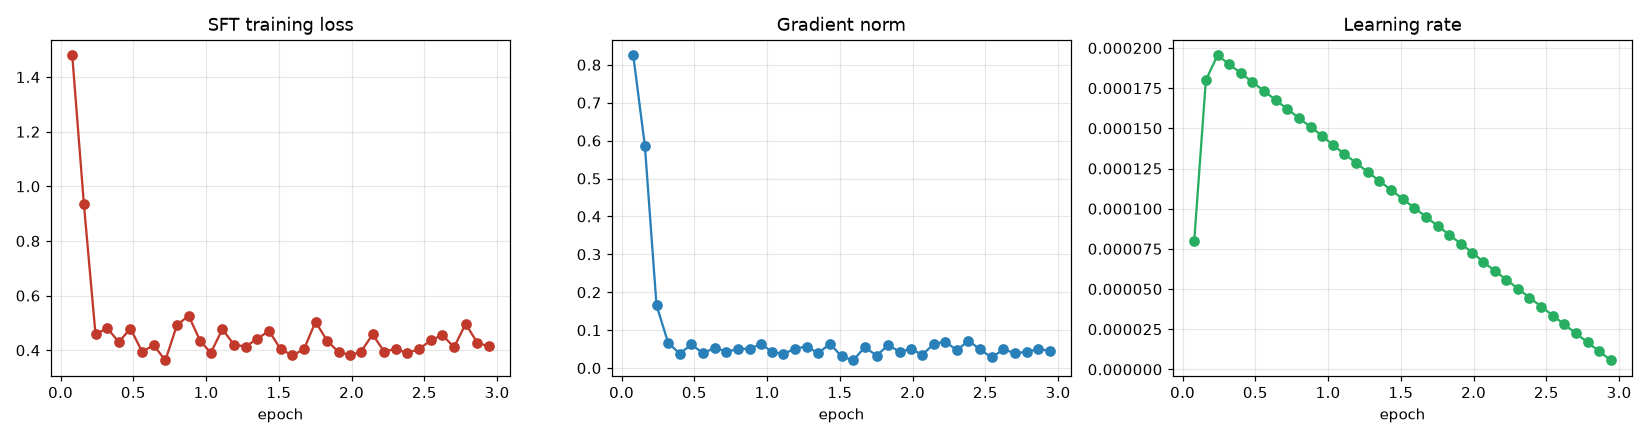

In [1]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_train_metrics.json"))
epochs = [r["epoch"] for r in records]
losses = [r["loss"] for r in records]
grad_norms = [r["grad_norm"] for r in records]
lrs = [r["learning_rate"] for r in records]
print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("SFT training loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Section 2: rejection-sampling rollout generation (current, in progress)

500/500 tasks done, 422 passed, 78 skipped, cost so far $1.41


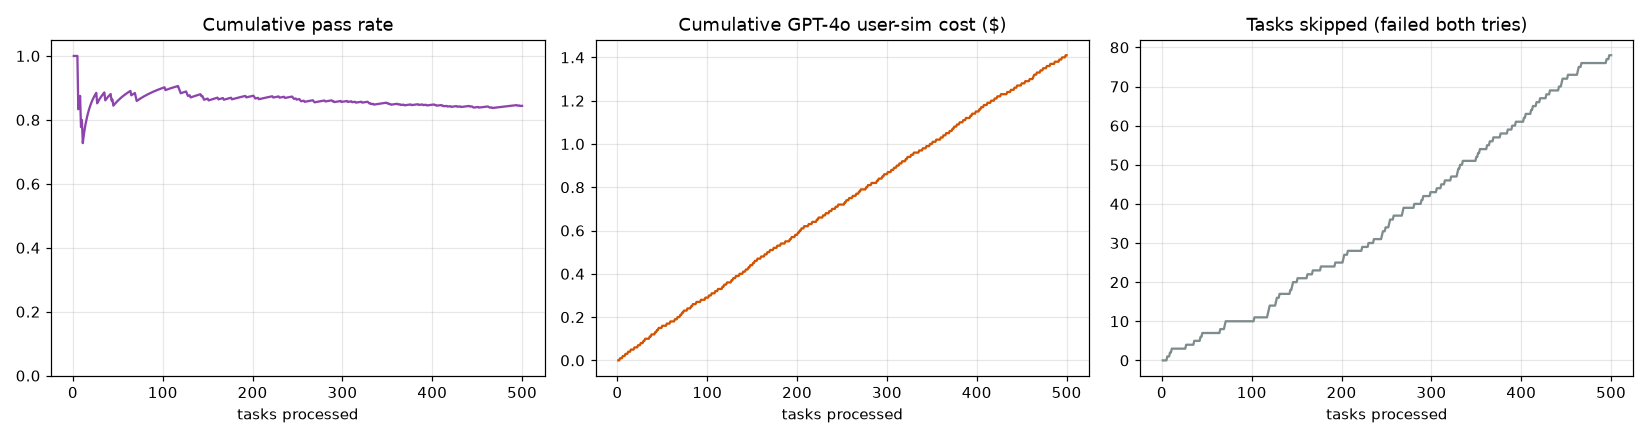

In [2]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/rollout_progress.json"))
if not records:
    print("no rollout progress data yet -- job may have just (re)started, try again in a few minutes")
else:
    task = [r["task"] for r in records]
    pass_rate = [r["passed"] / r["task"] for r in records]
    cost = [r["cost"] for r in records]
    skipped = [r["skipped"] for r in records]
    latest = records[-1]
    print(f"{latest['task']}/{latest['total']} tasks done, {latest['passed']} passed, {latest['skipped']} skipped, cost so far ${latest['cost']:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(task, pass_rate, color="#8e44ad"); axes[0].set_title("Cumulative pass rate"); axes[0].set_xlabel("tasks processed"); axes[0].set_ylim(0, 1.05); axes[0].grid(alpha=0.3)
    axes[1].plot(task, cost, color="#d35400"); axes[1].set_title("Cumulative GPT-4o user-sim cost ($)"); axes[1].set_xlabel("tasks processed"); axes[1].grid(alpha=0.3)
    axes[2].plot(task, skipped, color="#7f8c8d"); axes[2].set_title("Tasks skipped (failed both tries)"); axes[2].set_xlabel("tasks processed"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 3: SFT on the 422 real multi-turn rollouts -- attempt 1 (superseded)

QLoRA r=16, 3 epochs, max_seq_length=16384, only the final epoch-3 adapter kept (`save_total_limit=1`). Training loss looked great (converged to 0.029) -- but loss dropped to near-zero (~0.003-0.03) by as early as epoch 0.3, a sign of fast memorization on only 422 examples. Confirmed at eval time: the model fired tool calls immediately with **fabricated placeholder values** (`user@example.com`, `"John Doe"`, zip `"12345"`) instead of asking the real user for missing info -- rote memorization of the training set's argument patterns, not learned behavior. The one intermediate checkpoint (epoch 2) had already been deleted by the time this was diagnosed, so there was no earlier snapshot to fall back to. Loss values below are reconstructed from the session's own progress log (the raw training log was overwritten when attempt 2 was launched).

27 logged steps, latest loss = 0.0109 at epoch 2.93


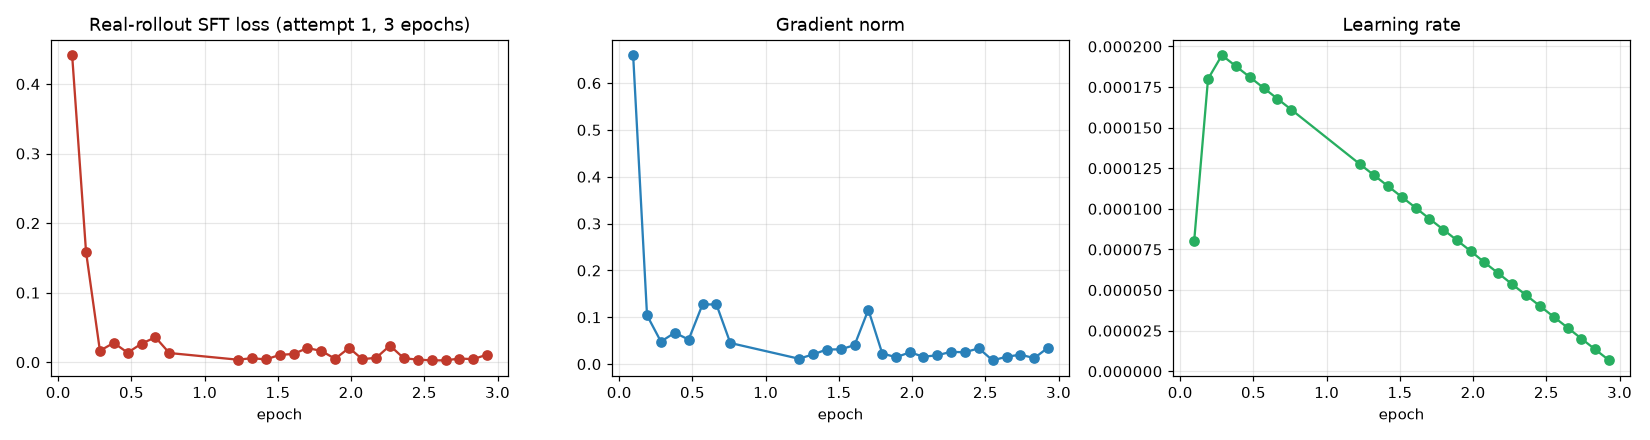

In [3]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_rollout_train_v1_metrics.json"))
epochs = [r["epoch"] for r in records]
losses = [r["loss"] for r in records]
grad_norms = [r["grad_norm"] for r in records]
lrs = [r["learning_rate"] for r in records]
print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("Real-rollout SFT loss (attempt 1, 3 epochs)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Section 4: SFT on the 422 real multi-turn rollouts -- attempt 2 (current)

Same data and LoRA config as attempt 1, but **1 epoch only** (~53 steps total) and **checkpointing every 5 steps** (`save_strategy="steps"`, `save_steps=5`, `save_total_limit=12`) instead of once at the end. Since attempt 1's loss was already suspiciously low by step 15-20, the goal is to grab and evaluate one of the very early checkpoints (step 5 first) before memorization sets in, rather than training to full convergence and hoping it generalizes.

1 logged steps, latest loss = 0.4413 at epoch 0.09


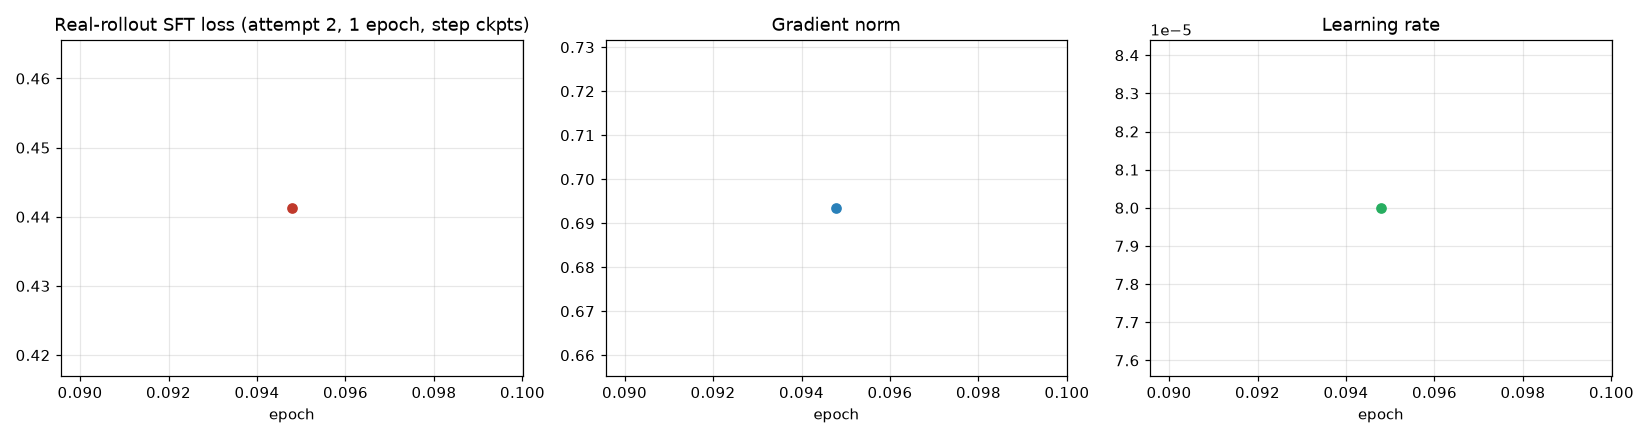

In [4]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/qwen3_14b_rollout_train_metrics.json"))
if not records:
    print("no training data yet -- job may still be downloading the base model")
else:
    epochs = [r["epoch"] for r in records]
    losses = [r["loss"] for r in records]
    grad_norms = [r["grad_norm"] for r in records]
    lrs = [r["learning_rate"] for r in records]
    print(f"{len(records)} logged steps, latest loss = {losses[-1]:.4f} at epoch {epochs[-1]:.2f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(epochs, losses, marker="o", color="#c0392b"); axes[0].set_title("Real-rollout SFT loss (attempt 2, 1 epoch, step ckpts)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, grad_norms, marker="o", color="#2980b9"); axes[1].set_title("Gradient norm"); axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.3)
    axes[2].plot(epochs, lrs, marker="o", color="#27ae60"); axes[2].set_title("Learning rate"); axes[2].set_xlabel("epoch"); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Section 5: τ-bench retail eval results, side by side

All runs are the full 115-task retail test split, GPT-4o as the user-simulator, same policy/tools/harness. **Baseline** is the untrained Qwen3-14B-AWQ. **Overfit** is the single-turn-SFT-trained model from Section 1 (catastrophic collapse). **Step 5** is the Section 4 run stopped at step 5 (~9% into epoch 1) -- essentially matches baseline, confirming that little training happened yet. Later checkpoints (step 10, 15...) get added here as they're evaluated, to find the point where real improvement (if any) shows up before memorization takes over.

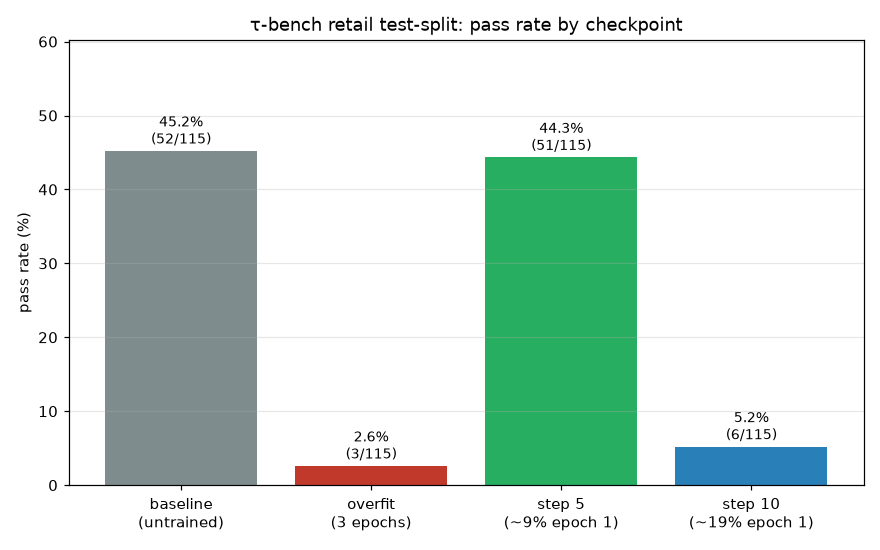

In [5]:
import json
import matplotlib.pyplot as plt

records = json.load(open("full_run_results/tau_eval_comparison.json"))
if not records:
    print("no eval comparison data yet")
else:
    labels = [r["label"] for r in records]
    pct = [100 * r["pass"] / r["total"] for r in records]
    colors = ["#7f8c8d", "#c0392b", "#27ae60", "#2980b9", "#8e44ad"][:len(records)]

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    bars = ax.bar(labels, pct, color=colors)
    for bar, r in zip(bars, records):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{100*r['pass']/r['total']:.1f}%\n({r['pass']}/{r['total']})", ha="center", fontsize=9)
    ax.set_ylabel("pass rate (%)")
    ax.set_title("τ-bench retail test-split: pass rate by checkpoint")
    ax.set_ylim(0, max(pct) + 15)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
